In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb


load data

In [2]:
df = pd.read_csv(r'sales_data_sample.csv',encoding='latin1')


understand the data

In [4]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


check the data types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


check for missing values

In [6]:
df.isna().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [7]:
df.shape

(2823, 25)

drop missing values

In [8]:
df.drop(columns='ADDRESSLINE2')

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,PHONE,ADDRESSLINE1,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,2125557818,897 Long Airport Avenue,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,26.47.1555,59 rue de l'Abbaye,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,6265557265,78934 Hillside Dr.,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,6505551386,7734 Strong St.,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,981-443655,Torikatu 38,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,61.77.6555,1 rue Alsace-Lorraine,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


this column has most of null values it would be better to ignore or drop this

fill missing values

In [9]:
df['STATE'].fillna('Unknown')

0            NY
1       Unknown
2       Unknown
3            CA
4            CA
         ...   
2818    Unknown
2819    Unknown
2820    Unknown
2821    Unknown
2822         MA
Name: STATE, Length: 2823, dtype: object

fill missing values

In [10]:
df['POSTALCODE'].fillna('Unknown')

0         10022
1         51100
2         75508
3         90003
4       Unknown
         ...   
2818      28034
2819      90110
2820      28034
2821      31000
2822      51003
Name: POSTALCODE, Length: 2823, dtype: object

TERRITORY           has 1074 =vlues fill them 

In [11]:
df['TERRITORY'].fillna('Unknown')

0       Unknown
1          EMEA
2          EMEA
3       Unknown
4       Unknown
         ...   
2818       EMEA
2819       EMEA
2820       EMEA
2821       EMEA
2822    Unknown
Name: TERRITORY, Length: 2823, dtype: object

In [17]:
df.shape

(2823, 25)

In [12]:
df.info()

# check the sales over year
df.groupby(['YEAR_ID'])['SALES'].sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


YEAR_ID
2004    4724162.60
2003    3516979.54
2005    1791486.71
Name: SALES, dtype: float64

2004 is the year with most sales

In [24]:
# 2004 has most sales

([<matplotlib.axis.XTick at 0x29d2e639e10>,
 [Text(2003, 0, '2003'), Text(2004, 0, '2004'), Text(2005, 0, '2005')])

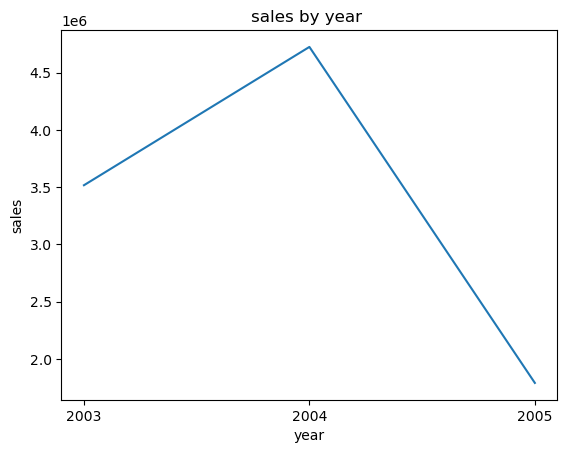

In [13]:
## line chart
plt.title('sales by year ')

df.groupby(['YEAR_ID'])['SALES'].sum().plot(kind='line')
plt.xlabel('year')
plt.ylabel('sales')
plt.xticks([2003,2004,2005])

2005 sales record is lowest 2005 data is also not completed

In [14]:
# HIGHEST SALES RECORD IN 2004 AND LOWEST SALES RECORD IN 2005

In [15]:
df.groupby(['PRODUCTLINE'])['SALES'].sum().sort_values(ascending=False)

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64

in last three year Classic Cars sold 3919615.66
highest sale

<Axes: xlabel='PRODUCTLINE'>

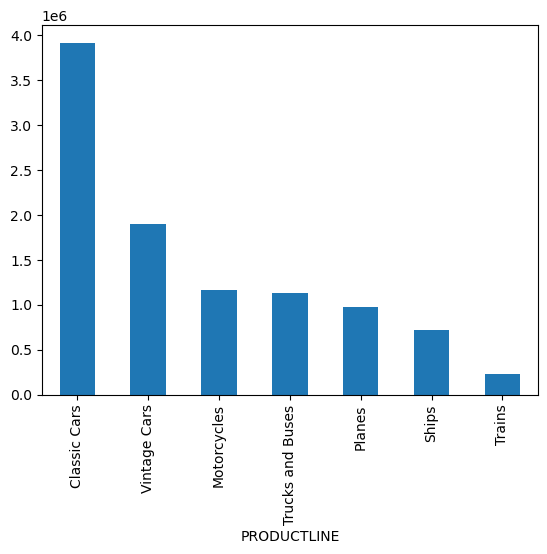

In [16]:
df.groupby(['PRODUCTLINE'])['SALES'].sum().sort_values(ascending=False).plot(kind='bar')

In [17]:
# # sb.barplot(data = df ,x ='PRODUCTLINE',y='SALES' )
# plt.title('Products with height sales')
# plt.xlabel('products')
# plt.ylabel('sales')
# plt.xticks(rotation=45)

In [ ]:
# classic cars sale record most around 4000+

In [18]:
# check sales by year
df.groupby(['YEAR_ID','PRODUCTLINE'])['SALES'].sum()#.idxmax()

YEAR_ID  PRODUCTLINE     
2003     Classic Cars        1484785.29
         Motorcycles          370895.58
         Planes               272257.60
         Ships                244821.09
         Trains                72802.29
         Trucks and Buses     420429.93
         Vintage Cars         650987.76
2004     Classic Cars        1762257.09
         Motorcycles          560545.23
         Planes               502671.80
         Ships                341437.97
         Trains               116523.85
         Trucks and Buses     529302.89
         Vintage Cars         911423.77
2005     Classic Cars         672573.28
         Motorcycles          234947.53
         Planes               200074.17
         Ships                128178.07
         Trains                36917.33
         Trucks and Buses     178057.02
         Vintage Cars         340739.31
Name: SALES, dtype: float64

2004 has most sale , with product Classic Cars

In [19]:
df.pivot_table(index='YEAR_ID',columns='PRODUCTLINE',values='SALES',aggfunc='sum')

PRODUCTLINE,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars
YEAR_ID,,,,,,,
2003,1484785.29,370895.58,272257.60,244821.09,72802.29,420429.93,650987.76
2004,1762257.09,560545.23,502671.80,341437.97,116523.85,529302.89,911423.77
2005,672573.28,234947.53,200074.17,128178.07,36917.33,178057.02,340739.31


in 2004 Class cars and moter cycles are on demand